In [6]:
import pandas as pd
import pulp

# Load your price data
file = "/Users/an-chilu/Desktop/Career/Past Projects/Energy-Plant-Optimization-Project/Prices.xlsx"
xls = pd.ExcelFile(file)
electric = pd.read_excel(file, sheet_name='PRICE_ELECTRIC')
gas = pd.read_excel(file, sheet_name='PRICE_GAS')

df = electric.merge(gas, on="OPERATING_DATE", how="left")

T = range(len(df))
units = [1, 2]

P_min = {1: 150, 2: 160}   # example
P_max = {1: 340, 2: 270}

SU = {1: 16500, 2: 7250}
ML = {1: 150*2.5, 2: 57*5}  # VOM * min load

ramp = {1: 20*60, 2: 30*60}  # convert to MW/hour

UT = {1: 2, 2: 1}
DT = {1: 2, 2: 1}

heat_rate = {1: 7.0, 2: 10.0}  # simplify

model = pulp.LpProblem("CCGT_PJM", pulp.LpMaximize)

u = pulp.LpVariable.dicts("u", (units, T), 0, 1, cat='Binary')
y = pulp.LpVariable.dicts("y", (units, T), 0, 1, cat='Binary')
p = pulp.LpVariable.dicts("p", (units, T), 0)

model += pulp.lpSum([
    df.loc[t, "NP15 ($/MWh)"] * p[i][t]
    - df.loc[t, "PG&E Citygate ($/MMBtu)"] * heat_rate[i] * p[i][t]
    - ML[i] * u[i][t]
    - SU[i] * y[i][t]
    for i in units for t in T
])

for i in units:
    for t in T:
        model += p[i][t] <= P_max[i] * u[i][t]
        model += p[i][t] >= P_min[i] * u[i][t]

for i in units:
    for t in T:
        if t > 0:
            model += y[i][t] >= u[i][t] - u[i][t-1]

for i in units:
    for t in T:
        if t > 0:
            model += p[i][t] - p[i][t-1] <= ramp[i]
            model += p[i][t-1] - p[i][t] <= ramp[i]

model.solve()

print("Status:", pulp.LpStatus[model.status])

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/an-chilu/Desktop/Career/Past Projects/Energy-Plant-Optimization-Project/venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/2s/pf3bmr2d1hdbcgx17_5vywdr0000gn/T/9143cafdd4c94318953ceb7e7906550d-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/2s/pf3bmr2d1hdbcgx17_5vywdr0000gn/T/9143cafdd4c94318953ceb7e7906550d-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1679 COLUMNS
At line 7714 RHS
At line 9389 BOUNDS
At line 10062 ENDATA
Problem MODEL has 1674 rows, 1008 columns and 3682 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 344938 - 0.00 seconds
Cgl0004I processed model has 1006 rows, 1006 columns (670 integer (670 of which binary)) and 2346 elements
Cbc0038I Initial state - 0 integers unsatisfied sum - 0
Cbc0038I So

In [8]:
df

,OPERATING_DATE,HOUR_ENDING,NP15 ($/MWh),PG&E Citygate ($/MMBtu)
0,2022-03-21,1,45.04,7.05
1,2022-03-21,2,43.63,7.05
2,2022-03-21,3,43.43,7.05
3,2022-03-21,4,43.42,7.05
4,2022-03-21,5,46.30,7.05
...,...,...,...,...
163,2022-03-27,20,94.18,7.41
164,2022-03-27,21,92.23,7.41
165,2022-03-27,22,75.27,7.41
166,2022-03-27,23,65.95,7.41


In [ ]:
# results = []

# for t in T:
#     results.append({
#         "OPERATING_DATE": df.loc[t, "OPERATING_DATE"],
#         "HOUR_ENDING": df.loc[t, "HOUR_ENDING"],
#         "PRICE_ELECTRIC": df.loc[t, "NP15 ($/MWh)"],
#         "PRICE_GAS": df.loc[t, "PG&E Citygate ($/MMBtu)"],
#         "MW_GENERATION_Unit1": p[1][t].value(),
#         "MW_GENERATION_Unit2": p[2][t].value()
#     })

# pd.DataFrame(results).to_csv("CCGT_PSEUDO.csv", index=False)

In [21]:
results = pd.read_csv('/Users/an-chilu/Desktop/Career/Past Projects/Energy-Plant-Optimization-Project/CCGT_PSEUDO.csv')
results.head(12)

,OPERATING_DATE,HOUR_ENDING,PRICE_ELECTRIC,PRICE_GAS,MW_GENERATION_Unit1,MW_GENERATION_Unit2
0,2022-03-21,1,45.04,7.05,150.0,0.0
1,2022-03-21,2,43.63,7.05,150.0,0.0
2,2022-03-21,3,43.43,7.05,150.0,0.0
3,2022-03-21,4,43.42,7.05,150.0,0.0
4,2022-03-21,5,46.30,7.05,150.0,0.0
5,2022-03-21,6,55.50,7.05,340.0,0.0
6,2022-03-21,7,76.70,7.05,340.0,0.0
7,2022-03-21,8,77.29,7.05,340.0,0.0
8,2022-03-21,9,51.19,7.05,340.0,0.0
9,2022-03-21,10,46.89,7.05,0.0,0.0


# Plot: MW vs. time

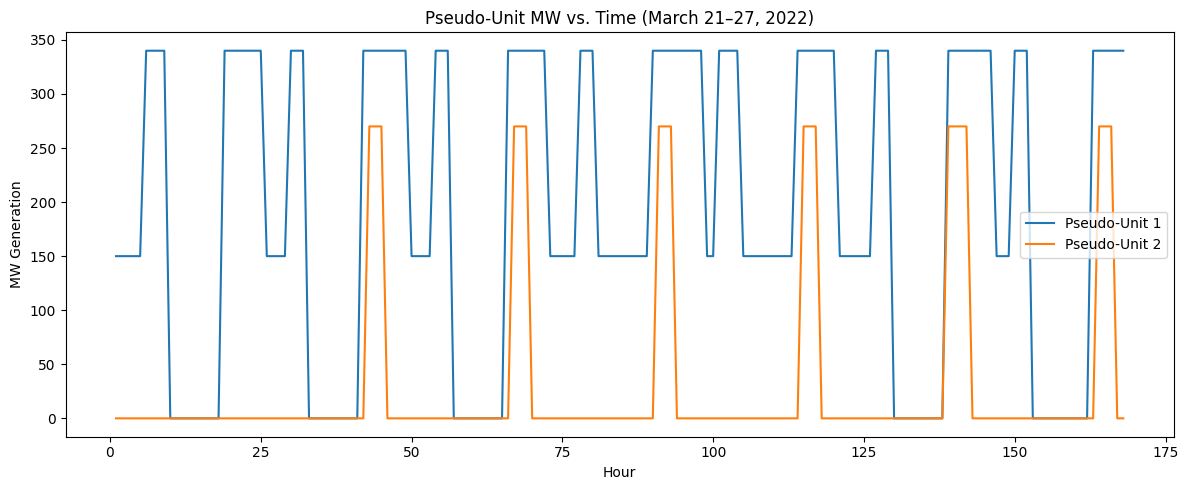

In [22]:
import matplotlib.pyplot as plt

results["TIME_INDEX"] = range(1, len(results) + 1)

plt.figure(figsize=(12, 5))
plt.plot(results["TIME_INDEX"], results["MW_GENERATION_Unit1"], label="Pseudo-Unit 1")
plt.plot(results["TIME_INDEX"], results["MW_GENERATION_Unit2"], label="Pseudo-Unit 2")
plt.xlabel("Hour")
plt.ylabel("MW Generation")
plt.title("Pseudo-Unit MW vs. Time (March 21–27, 2022)")
plt.legend()
plt.tight_layout();

In [23]:
results_2 = []

for t in T:
    row = {
        "OPERATING_DATE": df.loc[t, "OPERATING_DATE"],
        "HOUR_ENDING": df.loc[t, "HOUR_ENDING"],
        "PRICE_ELECTRIC": df.loc[t, "NP15 ($/MWh)"],
        "PRICE_GAS": df.loc[t, "PG&E Citygate ($/MMBtu)"],
    }

    for i in units:
        row[f"u_{i}"] = u[i][t].varValue
        row[f"y_{i}"] = y[i][t].varValue
        row[f"MW_GENERATION_Unit{i}"] = p[i][t].varValue

    results_2.append(row)

results_df = pd.DataFrame(results_2)

print(results_df.head())

  OPERATING_DATE  HOUR_ENDING  PRICE_ELECTRIC  PRICE_GAS  u_1  y_1  \
0     2022-03-21            1           45.04       7.05  1.0  0.0   
1     2022-03-21            2           43.63       7.05  1.0  0.0   
2     2022-03-21            3           43.43       7.05  1.0  0.0   
3     2022-03-21            4           43.42       7.05  1.0  0.0   
4     2022-03-21            5           46.30       7.05  1.0  0.0   

   MW_GENERATION_Unit1  u_2  y_2  MW_GENERATION_Unit2  
0                150.0  0.0  0.0                  0.0  
1                150.0  0.0  0.0                  0.0  
2                150.0  0.0  0.0                  0.0  
3                150.0  0.0  0.0                  0.0  
4                150.0  0.0  0.0                  0.0  


In [29]:
summary = []

num_hours = len(results_df)

for i in units:
    generation = results_df[f"MW_GENERATION_Unit{i}"]
    on_status = results_df[f"u_{i}"]
    starts = results_df[f"y_{i}"]

    # Revenue
    total_revenue = (results_df["PRICE_ELECTRIC"] * generation).sum()

    # Fuel costs
    fuel_costs = (results_df["PRICE_GAS"] * heat_rate[i] * generation).sum()

    # Minimum load / operating costs
    ml_costs = (ML[i] * on_status).sum()

    # Startup costs
    startup_costs = (SU[i] * starts).sum()

    # Total costs
    total_costs = fuel_costs + ml_costs + startup_costs

    # Gross margin
    gross_margin = total_revenue - total_costs

    # Gross margin in $/kW
    gross_margin_per_kw = gross_margin / (P_max[i] * 1000)

    # Capacity factor (%)
    capacity_factor = generation.sum() / (P_max[i] * num_hours) * 100

    # Number of starts
    num_starts = starts.sum()

    summary.append({
        "Unit": f"Pseudo-Unit {i}",
        "Gross Margin ($/kW)": gross_margin_per_kw,
        "Capacity Factor (%)": capacity_factor,
        "Total Revenue ($)": total_revenue,
        "Total Costs ($)": total_costs,
        "Fuel Costs ($)": fuel_costs,
        "Number of Starts": num_starts
    })

summary_df = pd.DataFrame(summary)
round(summary_df, 2)

,Unit,Gross Margin ($/kW),Capacity Factor (%),Total Revenue ($),Total Costs ($),Fuel Costs ($),Number of Starts
0,Pseudo-Unit 1,0.91,56.99,2053562.9,1743628.1,1615378.1,5.0
1,Pseudo-Unit 2,0.13,11.31,449471.7,414468.0,365553.0,6.0
